# 1.FACEBOOK GRAPH CONSTRUCTION

POST-POST HOMOPHILY GRAPH

In [4]:
import pandas as pd
import networkx as nx
from itertools import combinations

# =====================================================
# LOAD FACEBOOK GRAPH DATASET
# =====================================================

df = pd.read_csv(
    "../../data_preprocess/processed_data/graph_data/facebook_graph.csv"
)

print("=" * 60)
print("FACEBOOK GRAPH DATA")
print("=" * 60)

print(df.shape)

FACEBOOK GRAPH DATA
(7527, 32)


In [5]:
import networkx as nx
from itertools import combinations
import numpy as np

G = nx.Graph()

# 1. THÊM NODES BẰNG VECTORIZATION (Nhanh hơn rất nhiều)
# Chuyển data sang dictionary để add_nodes_from xử lý một lần
node_attrs = df.set_index('post_id')[['topic', 'language', 'media_type', 'location', 'followers', 'popularity']].to_dict('index')
G.add_nodes_from(node_attrs.items())
print(f"\nNodes added: {G.number_of_nodes()}")

# 2. CHUẨN BỊ DỮ LIỆU ĐỂ TẠO EDGES
# Chỉ lấy các cột cần thiết và chuyển sang Numpy Array hoặc List thuần
# Cấu trúc index: 0: post_id, 1: topic, 2: language, 3: media_type, 4: user_id, 5: followers
columns_needed = ['post_id', 'topic', 'language', 'media_type', 'user_id', 'followers']
records = df[columns_needed].values.tolist() 

# 3. TẠO EDGES TỐI ƯU
edges_to_add = []

for row_i, row_j in combinations(records, 2):
    score = 0
    
    # So sánh trực tiếp qua index của tuple/list (cực nhanh)
    if row_i[1] == row_j[1]: score += 2  # topic
    if row_i[2] == row_j[2]: score += 1  # language
    if row_i[3] == row_j[3]: score += 1  # media_type
    if row_i[4] == row_j[4]: score += 3  # user_id
    
    # Tính follower_ratio tối ưu (tránh gọi hàm min/max nhiều lần)
    f_i, f_j = row_i[5], row_j[5]
    if f_i > 0 and f_j > 0: # Tránh lỗi chia cho 0
        ratio = f_i / f_j if f_i < f_j else f_j / f_i
        if ratio >= 0.8:
            score += 1
            
    # Lọc và lưu vào list
    if score >= 3:
        edges_to_add.append((row_i[0], row_j[0], score)) # (node_u, node_v, weight)

# Add edges hàng loạt (Bulk insert) thay vì add từng cái
G.add_weighted_edges_from(edges_to_add)

print(f"\nEdges created: {G.number_of_edges()}")


Nodes added: 7527

Edges created: 1165053


In [6]:
import pandas as pd
import numpy as np
from itertools import combinations
import time

# Bắt đầu tính thời gian chạy
start_time = time.time()

# =====================================================
# 1. TẠO FILE FACEBOOK_NODE.CSV
# =====================================================
print("Đang tạo file Nodes...")

# Gephi yêu cầu cột ID chính phải có tên là "Id" (viết hoa chữ I)
# Nên tạo thêm cột "Label" để hiển thị text trên Gephi
nodes_df = df.copy()
nodes_df = nodes_df.rename(columns={"post_id": "Id"})
nodes_df["Label"] = nodes_df["Id"].astype(str) # Dùng ID làm Label luôn, hoặc bạn có thể đổi thành tên bài viết

# Chọn các cột thuộc tính muốn giữ lại để filter/tô màu trên Gephi
node_cols = ["Id", "Label", "topic", "language", "media_type", "location", "followers", "popularity", "user_id"]
nodes_export = nodes_df[node_cols]

# Xuất ra CSV
nodes_export.to_csv("facebook_node.csv", index=False, encoding='utf-8')
print(f"✅ Đã lưu facebook_node.csv với {len(nodes_export)} nodes.")

# =====================================================
# 2. TẠO FILE FACEBOOK_EDGE.CSV (Logic Tối Ưu)
# =====================================================
print("Đang tạo file Edges (Quá trình này có thể mất vài giây/phút tùy số lượng data)...")

# Trích xuất dữ liệu ra List thuần để chạy vòng lặp cực nhanh
columns_needed = ['post_id', 'topic', 'language', 'media_type', 'user_id', 'followers']
records = df[columns_needed].values.tolist() 

edges_data = []

for row_i, row_j in combinations(records, 2):
    score = 0
    
    # row_i[1]=topic, row_i[2]=language, row_i[3]=media_type, row_i[4]=user_id, row_i[5]=followers
    if row_i[1] == row_j[1]: score += 2  
    if row_i[2] == row_j[2]: score += 1  
    if row_i[3] == row_j[3]: score += 1  
    if row_i[4] == row_j[4]: score += 3  
    
    # Follower ratio
    f_i, f_j = row_i[5], row_j[5]
    if f_i > 0 and f_j > 0:
        ratio = f_i / f_j if f_i < f_j else f_j / f_i
        if ratio >= 0.8:
            score += 1
            
    # Lọc threshold >= 3
    if score >= 3:
        # Chuẩn bị dict theo format Gephi: Source, Target, Weight, Type
        edges_data.append({
            "Source": row_i[0],
            "Target": row_j[0],
            "Weight": score,
            "Type": "Undirected"  # Ghi rõ là đồ thị vô hướng
        })

# Chuyển list các cạnh thành DataFrame
edges_df = pd.DataFrame(edges_data)

# Xuất ra CSV
edges_df.to_csv("facebook_edge.csv", index=False, encoding='utf-8')
print(f"✅ Đã lưu facebook_edge.csv với {len(edges_df)} edges.")

# Tính tổng thời gian
print(f"⏱️ Tổng thời gian chạy: {round(time.time() - start_time, 2)} giây.")

Đang tạo file Nodes...
✅ Đã lưu facebook_node.csv với 7527 nodes.
Đang tạo file Edges (Quá trình này có thể mất vài giây/phút tùy số lượng data)...
✅ Đã lưu facebook_edge.csv với 1165053 edges.
⏱️ Tổng thời gian chạy: 24.99 giây.


In [7]:
import pandas as pd

graph_df = pd.read_csv(
    "facebook-result-1.csv"
)

print("\n" + "=" * 60)
print("GRAPH FEATURES DATA")
print("=" * 60)

print(graph_df.shape)

print("\nColumns:")
print(graph_df.columns.tolist())


GRAPH FEATURES DATA
(7527, 14)

Columns:
['Id', 'topic', 'language', 'media_type', 'location', 'followers', 'popularity', 'user_id', 'pageranks', 'Authority', 'Hub', 'Degree', 'Weighted Degree', 'modularity_class']


In [8]:
# SELECT ONLY USEFUL GRAPH FEATURES
# =====================================================

graph_features = graph_df[[
    
    "Id",
    "pageranks",
    "Authority",
    "Hub",
    "Degree",
    "Weighted Degree",
    "modularity_class"
]]
graph_features = graph_features.rename(
    columns={
        "Id": "post_id"
    }
)

print("\nGraph Features Shape:")
print(graph_features.shape)



Graph Features Shape:
(7527, 7)


In [9]:
original_df = df.copy()

# =====================================================
# REMOVE DUPLICATES
# =====================================================

original_df = original_df.drop_duplicates(
    subset=["post_id"]
)

In [10]:
# MERGE POST_ID BACK TO TRAIN/TEST
# =====================================================
# We need mapping between rows
# =====================================================

# recreate metadata version
metadata_df = original_df.copy()

remove_cols = [
    
    "timestamp",
    "date",
    "platform",
    "likes",
    "shares",
    "comments",
    "views",
    "total_engagement",
    "engagement_rate_per_1k_followers",
    "viral_coefficient",
    "cross_platform_spread",
    "hours_since_post"
]

existing_remove_cols = [

    col for col in remove_cols
    if col in metadata_df.columns
]

metadata_df = metadata_df.drop(
    columns=existing_remove_cols
)


In [11]:
# =====================================================
# ONE-HOT ENCODING
# =====================================================

categorical_cols = [

    "topic",
    "language",
    "media_type",
    "sentiment_category",
    "location"
]

existing_categorical_cols = [

    col for col in categorical_cols
    if col in metadata_df.columns
]

metadata_df = pd.get_dummies(

    metadata_df,

    columns=existing_categorical_cols,

    drop_first=True
)


In [12]:
# LOAD FACEBOOK TRAIN / TEST
# =====================================================

train_df = pd.read_csv(
    "../../data_preprocess/processed_data/ml_data/facebook_train.csv"
)

test_df = pd.read_csv(
    "../../data_preprocess/processed_data/ml_data/facebook_test.csv"
)

print("=" * 60)
print("METADATA DATASETS")
print("=" * 60)

print("Train Shape:", train_df.shape)
print("Test Shape :", test_df.shape)

METADATA DATASETS
Train Shape: (6021, 58)
Test Shape : (1506, 58)


In [13]:
# MERGE TRAIN
# =====================================================

train_hybrid = train_df.merge(

    graph_features,

    on="post_id",
    how="left"
)

# =====================================================
# MERGE TEST
# =====================================================

test_hybrid = test_df.merge(

    graph_features,

    on="post_id",
    how="left"
)

In [14]:
# CHECK MISSING GRAPH FEATURES
# =====================================================

print("\n" + "=" * 60)
print("MISSING VALUES CHECK")
print("=" * 60)

print("\nTrain Missing:")

print(
    train_hybrid[
        [
            "pageranks",
            "Degree"
        ]
    ].isnull().sum()
)

print("\nTest Missing:")

print(
    test_hybrid[
        [
            "pageranks",
            "Degree"
        ]
    ].isnull().sum()
)



MISSING VALUES CHECK

Train Missing:
pageranks    0
Degree       0
dtype: int64

Test Missing:
pageranks    0
Degree       0
dtype: int64


In [15]:
# FILL MISSING VALUES
# =====================================================
# some nodes may not exist in graph export
# =====================================================

graph_cols = [

    "pageranks",
    "Authority",
    "Hub",
    "Degree",
    "Weighted Degree",
    "modularity_class"
]

train_hybrid[graph_cols] = train_hybrid[
    graph_cols
].fillna(0)

test_hybrid[graph_cols] = test_hybrid[
    graph_cols
].fillna(0)

print("\n" + "=" * 60)
print("HYBRID DATASETS")
print("=" * 60)

print("Train Hybrid:", train_hybrid.shape)
print("Test Hybrid :", test_hybrid.shape)


HYBRID DATASETS
Train Hybrid: (6021, 64)
Test Hybrid : (1506, 64)


In [16]:
# SAVE HYBRID DATASETS
# =====================================================

train_hybrid.to_csv(
    "facebook_hybrid_train.csv",
    index=False
)

test_hybrid.to_csv(
    "facebook_hybrid_test.csv",
    index=False
)

In [17]:
# =====================================================
# FACEBOOK HYBRID MODEL
# METADATA + GRAPH FEATURES
# =====================================================

from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

In [18]:
# LOAD HYBRID DATASETS
# =====================================================

train_df = pd.read_csv(
    "facebook_hybrid_train.csv"
)

test_df = pd.read_csv(
    "facebook_hybrid_test.csv"
)

print("=" * 60)
print("HYBRID DATASETS")
print("=" * 60)

print("Train Shape:", train_df.shape)
print("Test Shape :", test_df.shape)

HYBRID DATASETS
Train Shape: (6021, 64)
Test Shape : (1506, 64)


In [19]:
# DROP ID COLUMNS
# =====================================================

drop_cols = [

    "post_id",
    "user_id"
]

existing_drop_cols = [

    col for col in drop_cols
    if col in train_df.columns
]

train_df = train_df.drop(
    columns=existing_drop_cols
)

test_df = test_df.drop(
    columns=existing_drop_cols
)

In [20]:
# SPLIT FEATURES / TARGET
# =====================================================

X_train = train_df.drop(
    columns=["popularity"]
)

y_train = train_df["popularity"]

X_test = test_df.drop(
    columns=["popularity"]
)

y_test = test_df["popularity"]

print("\nX_train Shape:", X_train.shape)
print("X_test Shape :", X_test.shape)


X_train Shape: (6021, 61)
X_test Shape : (1506, 61)


In [21]:
# XGBOOST MODEL
# =====================================================

model = XGBClassifier(

    objective="binary:logistic",

    eval_metric="logloss",

    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,

    random_state=42,

    n_jobs=-1
)

In [22]:
# TRAIN MODEL
# =====================================================

print("\n" + "=" * 60)
print("TRAINING HYBRID MODEL...")
print("=" * 60)

model.fit(
    X_train,
    y_train
)


TRAINING HYBRID MODEL...


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [23]:
# PREDICTIONS
# =====================================================

y_pred = model.predict(X_test)

y_prob = model.predict_proba(X_test)[:, 1]

In [24]:
# EVALUATION
# =====================================================

accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred
)

recall = recall_score(
    y_test,
    y_pred
)

f1 = f1_score(
    y_test,
    y_pred
)

roc_auc = roc_auc_score(
    y_test,
    y_prob
)

In [25]:
# CLASSIFICATION REPORT
# =====================================================

print("\n" + "=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)

print(
    classification_report(
        y_test,
        y_pred
    )
)

print(f"ROC-AUC  : {roc_auc:.4f}")


CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.86      0.94      0.90      1204
           1       0.64      0.40      0.49       302

    accuracy                           0.83      1506
   macro avg       0.75      0.67      0.70      1506
weighted avg       0.82      0.83      0.82      1506

ROC-AUC  : 0.8512


In [26]:
# CONFUSION MATRIX
# =====================================================

cm = confusion_matrix(
    y_test,
    y_pred
)

print("\n" + "=" * 60)
print("CONFUSION MATRIX")
print("=" * 60)

print(cm)


CONFUSION MATRIX
[[1135   69]
 [ 181  121]]


In [27]:
# FEATURE IMPORTANCE
# =====================================================

importance_df = pd.DataFrame({

    "feature": X_train.columns,
    "importance": model.feature_importances_

})

importance_df = importance_df.sort_values(
    by="importance",
    ascending=False
)

print("\n" + "=" * 60)
print("TOP 20 IMPORTANT FEATURES")
print("=" * 60)

print(
    importance_df.head(20)
)


TOP 20 IMPORTANT FEATURES
                feature  importance
3             followers    0.165969
39      language_German    0.027659
24      topic_Education    0.023779
36     language_Chinese    0.022664
32        topic_Science    0.020958
54     location_Unknown    0.020634
35         topic_Travel    0.019935
0           hour_of_day    0.019287
44     language_Spanish    0.019233
57                  Hub    0.018469
34     topic_Technology    0.018415
42      language_Korean    0.018349
33         topic_Sports    0.018162
49        location_Asia    0.017985
38      language_French    0.017957
9    sentiment_negative    0.017914
10       toxicity_score    0.017887
25  topic_Entertainment    0.017783
16            has_media    0.017372
60     modularity_class    0.017254


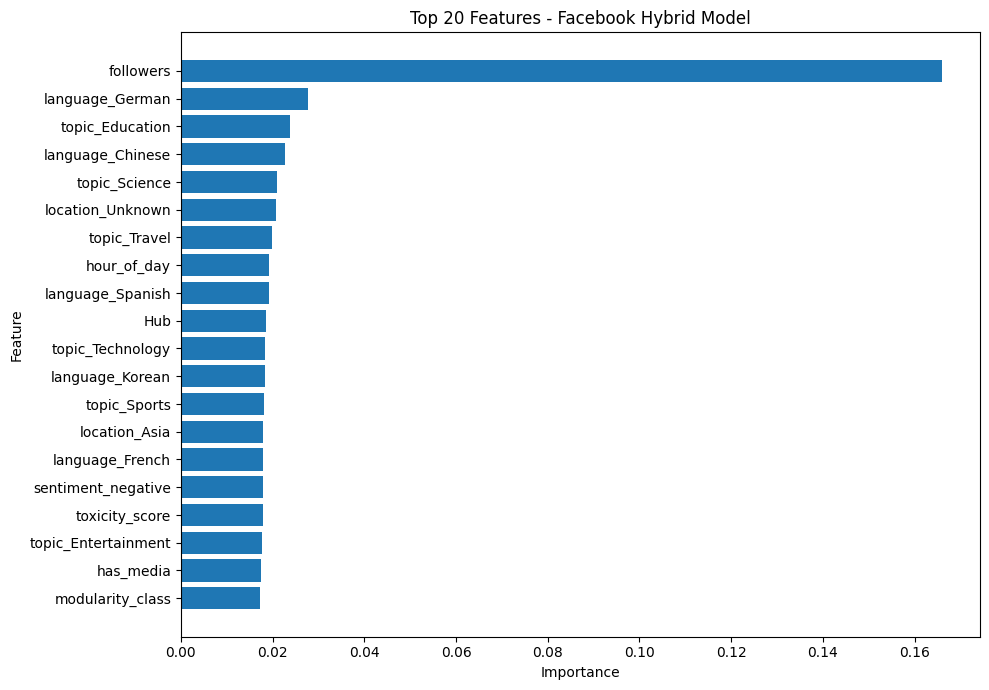

In [28]:
# PLOT TOP FEATURES
# =====================================================
import matplotlib.pyplot as plt

top_n = 20

plot_df = importance_df.head(top_n)

plt.figure(figsize=(10, 7))

plt.barh(
    plot_df["feature"][::-1],
    plot_df["importance"][::-1]
)

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.title(
    "Top 20 Features - Facebook Hybrid Model"
)

plt.tight_layout()

plt.show()

# 2. FACEBOOK NODE2VEC

 GRAPH EMBEDDING

In [29]:
# LOAD GRAPH FEATURES FILE
# =====================================================
import pandas as pd

graph_df = pd.read_csv(
    "facebook-result-1.csv"
)

print("=" * 60)
print("GRAPH DATA")
print("=" * 60)

print(graph_df.shape)


GRAPH DATA
(7527, 14)


In [30]:
# CREATE NETWORKX GRAPH
# =====================================================

G = nx.Graph()

# =====================================================
# ADD NODES
# =====================================================

for idx, row in graph_df.iterrows():

    G.add_node(
        row["Id"]
    )

# =====================================================
# CREATE EDGES
# =====================================================
# IMPORTANT:
# Need original graph edge list
# =====================================================

# If you exported edge list from Gephi:
# load it here

edges_df = pd.read_csv(
    "facebook_edge.csv"
)

print("\nEdges Shape:")
print(edges_df.shape)

# =====================================================
# ADD EDGES
# =====================================================

for idx, row in edges_df.iterrows():

    source = row["Source"]
    target = row["Target"]

    # optional weight
    if "Weight" in edges_df.columns:

        G.add_edge(
            source,
            target,
            weight=row["Weight"]
        )

    else:

        G.add_edge(
            source,
            target
        )

print("\nGraph Created 🚀")

print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())


Edges Shape:
(1165053, 4)

Graph Created 🚀
Nodes: 7527
Edges: 1165053


In [31]:
# NODE2VEC
# =====================================================
from node2vec import Node2Vec

print("\n" + "=" * 60)
print("TRAINING NODE2VEC...")
print("=" * 60)

node2vec = Node2Vec(

    G,

    dimensions=16,
    walk_length=10,
    num_walks=20,

    workers=4,

    seed=42
)

model = node2vec.fit(

    window=5,
    min_count=1,
    batch_words=4
)



TRAINING NODE2VEC...


Computing transition probabilities:   0%|          | 0/7527 [00:00<?, ?it/s]

c:\Users\khoav\anaconda3\envs\graphenv\Lib\site-packages\joblib\externals\loky\process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


PicklingError: Could not pickle the task to send it to the workers.

In [ ]:
# CREATE EMBEDDING DATAFRAME
# =====================================================

embeddings = []

for node in G.nodes():

    vector = model.wv[str(node)]

    row_data = {

        "post_id": node
    }

    # embedding dimensions
    for i in range(len(vector)):

        row_data[f"n2v_{i}"] = vector[i]

    embeddings.append(row_data)

embedding_df = pd.DataFrame(
    embeddings
)

print("\nEmbedding Shape:")
print(embedding_df.shape)

In [ ]:
# SAVE EMBEDDINGS
# =====================================================

embedding_df.to_csv(
    "facebook_node2vec_embeddings.csv",
    index=False
)

print("\nNode2Vec embeddings saved 🚀")

In [ ]:
# FACEBOOK NODE2VEC HYBRID MODEL
# METADATA + NODE2VEC EMBEDDINGS
# =====================================================

import pandas as pd
import numpy as np

from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

import matplotlib.pyplot as plt

In [ ]:
# LOAD TRAIN / TEST DATA
# =====================================================

train_df = pd.read_csv(
    "../../data_preprocess/processed_data/ml_data/facebook_train.csv"
)

test_df = pd.read_csv(
    "../../data_preprocess/processed_data/ml_data/facebook_test.csv"
)

print("=" * 60)
print("METADATA DATA")
print("=" * 60)

print("Train Shape:", train_df.shape)
print("Test Shape :", test_df.shape)

In [ ]:
#LOAD NODE2VEC EMBEDDINGS
# =====================================================

embedding_df = pd.read_csv(
    "facebook_node2vec_embeddings.csv"
)

print("\n" + "=" * 60)
print("NODE2VEC EMBEDDINGS")
print("=" * 60)

print(embedding_df.shape)

print("\nEmbedding Columns:")
print(embedding_df.columns[:10])

In [ ]:
# MERGE TRAIN
# =====================================================

train_hybrid = train_df.merge(

    embedding_df,

    on="post_id",
    how="left"
)

# =====================================================
# MERGE TEST
# =====================================================

test_hybrid = test_df.merge(

    embedding_df,

    on="post_id",
    how="left"
)

# =====================================================
# CHECK MISSING VALUES
# =====================================================

print("\n" + "=" * 60)
print("MISSING EMBEDDINGS CHECK")
print("=" * 60)

embedding_cols = [

    col for col in embedding_df.columns
    if col.startswith("n2v_")
]

print("\nTrain Missing:")

print(
    train_hybrid[
        embedding_cols
    ].isnull().sum().sum()
)

print("\nTest Missing:")

print(
    test_hybrid[
        embedding_cols
    ].isnull().sum().sum()
)

# =====================================================
# FILL MISSING EMBEDDINGS
# =====================================================

train_hybrid[embedding_cols] = train_hybrid[
    embedding_cols
].fillna(0)

test_hybrid[embedding_cols] = test_hybrid[
    embedding_cols
].fillna(0)

# =====================================================
# DROP ID COLUMNS
# =====================================================

drop_cols = [

    "post_id",
    "user_id"
]

existing_drop_cols = [

    col for col in drop_cols
    if col in train_hybrid.columns
]

train_hybrid = train_hybrid.drop(
    columns=existing_drop_cols
)

test_hybrid = test_hybrid.drop(
    columns=existing_drop_cols
)

In [ ]:
# SPLIT FEATURES / TARGET
# =====================================================

X_train = train_hybrid.drop(
    columns=["popularity"]
)

y_train = train_hybrid["popularity"]

X_test = test_hybrid.drop(
    columns=["popularity"]
)

y_test = test_hybrid["popularity"]

print("\n" + "=" * 60)
print("FINAL DATA")
print("=" * 60)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)


In [ ]:
# =====================================================
# XGBOOST MODEL
# =====================================================

model = XGBClassifier(

    objective="binary:logistic",

    eval_metric="logloss",

    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,

    subsample=0.8,
    colsample_bytree=0.8,

    random_state=42,

    n_jobs=-1
)

# =====================================================
# TRAIN MODEL
# =====================================================

print("\n" + "=" * 60)
print("TRAINING NODE2VEC HYBRID MODEL...")
print("=" * 60)

model.fit(
    X_train,
    y_train
)

print("Training completed 🚀")

# =====================================================
# PREDICTIONS
# =====================================================

y_pred = model.predict(X_test)

y_prob = model.predict_proba(X_test)[:, 1]

# =====================================================
# EVALUATION
# =====================================================

accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred
)

recall = recall_score(
    y_test,
    y_pred
)

f1 = f1_score(
    y_test,
    y_pred
)

roc_auc = roc_auc_score(
    y_test,
    y_prob
)

In [ ]:
# =====================================================
# CLASSIFICATION REPORT
# =====================================================

print("\n" + "=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)

print(
    classification_report(
        y_test,
        y_pred
    )
)
print(f"ROC-AUC  : {roc_auc:.4f}")

In [ ]:
# FEATURE IMPORTANCE
# =====================================================

importance_df = pd.DataFrame({

    "feature": X_train.columns,
    "importance": model.feature_importances_

})

importance_df = importance_df.sort_values(
    by="importance",
    ascending=False
)

print("\n" + "=" * 60)
print("TOP 20 IMPORTANT FEATURES")
print("=" * 60)

print(
    importance_df.head(20)
)

In [ ]:
# =====================================================

top_n = 20

plot_df = importance_df.head(top_n)

plt.figure(figsize=(10, 7))

plt.barh(
    plot_df["feature"][::-1],
    plot_df["importance"][::-1]
)

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.title(
    "Top Features - Facebook Node2Vec Hybrid"
)

plt.tight_layout()

plt.show()